In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10, 6)

In [3]:
df=pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


In [4]:
print("Shape:",df.shape)
df.info()

Shape: (6097, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6097 entries, 0 to 6096
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        6097 non-null   int64  
 1   track_id          6097 non-null   object 
 2   artists           6097 non-null   object 
 3   album_name        6097 non-null   object 
 4   track_name        6097 non-null   object 
 5   popularity        6096 non-null   float64
 6   duration_ms       6096 non-null   float64
 7   explicit          6096 non-null   object 
 8   danceability      6096 non-null   float64
 9   energy            6096 non-null   float64
 10  key               6096 non-null   float64
 11  loudness          6096 non-null   float64
 12  mode              6096 non-null   float64
 13  speechiness       6096 non-null   float64
 14  acousticness      6096 non-null   float64
 15  instrumentalness  6096 non-null   float64
 16  liveness          6096 n

In [5]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical features: ['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']


In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,6097.000000,6096.000000,6.096000e+03,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000,6096.000000
mean,3048.000000,36.305446,2.296678e+05,0.532989,0.591847,5.351542,-9.291292,0.617782,0.064338,0.353448,0.223678,0.179907,0.452787,119.991483,3.881562
std,1760.196627,23.765035,8.304413e+04,0.169291,0.284866,3.553774,6.332752,0.485969,0.061764,0.363577,0.361776,0.152103,0.265503,30.543882,0.453677
min,0.000000,0.000000,3.182400e+04,0.000000,0.001440,0.000000,-41.808000,0.000000,0.000000,0.000001,0.000000,0.014400,0.000000,0.000000,0.000000
25%,1524.000000,18.000000,1.827295e+05,0.424000,0.359000,2.000000,-10.822250,0.000000,0.033775,0.019500,0.000000,0.094700,0.223000,96.469250,4.000000
50%,3048.000000,43.000000,2.217330e+05,0.542000,0.654500,5.000000,-7.300000,1.000000,0.043000,0.196000,0.000267,0.117500,0.431000,119.627000,4.000000
75%,4572.000000,54.000000,2.616400e+05,0.659000,0.844000,8.000000,-5.268000,1.000000,0.065400,0.724000,0.432000,0.218000,0.668000,140.065000,4.000000
max,6096.000000,93.000000,1.478618e+06,0.974000,1.000000,11.000000,0.698000,1.000000,0.924000,0.996000,0.988000,0.992000,0.995000,220.081000,5.000000


In [7]:
print("Missing values:\n",df.isnull().sum())
print("\nDuplicate rows:",df.duplicated().sum())
df=df.drop_duplicates()
df=df.dropna()

Missing values:
 Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          1
duration_ms         1
explicit            1
danceability        1
energy              1
key                 1
loudness            1
mode                1
speechiness         1
acousticness        1
instrumentalness    1
liveness            1
valence             1
tempo               1
time_signature      1
track_genre         1
dtype: int64

Duplicate rows: 0


In [8]:
corr=df[numerical_cols].corr()
corr

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0,1.000000,0.158789,-0.000611,-0.290976,-0.012055,-0.008542,-0.173894,-0.118560,0.087991,-0.017747,0.330309,0.023230,-0.289012,-0.008159,-0.066959
popularity,0.158789,1.000000,-0.033597,-0.116527,-0.167025,-0.024244,-0.119653,0.003519,-0.077017,0.142028,0.069186,-0.041293,-0.218217,-0.026679,-0.028585
duration_ms,-0.000611,-0.033597,1.000000,-0.079338,0.136155,0.018600,0.119078,-0.027118,-0.053731,-0.160430,-0.060817,0.028812,-0.053852,0.034241,0.042823
danceability,-0.290976,-0.116527,-0.079338,1.000000,0.268307,0.051257,0.352566,-0.023705,0.168145,-0.220489,-0.311148,0.008646,0.577182,-0.038171,0.227721
energy,-0.012055,-0.167025,0.136155,0.268307,1.000000,0.063520,0.814643,-0.050157,0.254399,-0.824409,-0.437272,0.232976,0.527787,0.217009,0.213268
key,-0.008542,-0.024244,0.018600,0.051257,0.063520,1.000000,0.051588,-0.113517,0.023073,-0.065628,-0.026497,-0.006186,0.063874,0.020117,0.017586
loudness,-0.173894,-0.119653,0.119078,0.352566,0.814643,0.051588,1.000000,0.019357,0.149582,-0.713160,-0.632125,0.168115,0.453426,0.201687,0.223617
mode,-0.118560,0.003519,-0.027118,-0.023705,-0.050157,-0.113517,0.019357,1.000000,-0.103986,0.047953,-0.112257,-0.005442,-0.019743,0.027208,0.001517
speechiness,0.087991,-0.077017,-0.053731,0.168145,0.254399,0.023073,0.149582,-0.103986,1.000000,-0.136414,-0.155452,0.128827,0.164544,0.089521,0.065698
acousticness,-0.017747,0.142028,-0.160430,-0.220489,-0.824409,-0.065628,-0.713160,0.047953,-0.136414,1.000000,0.401021,-0.174328,-0.396108,-0.190895,-0.189692


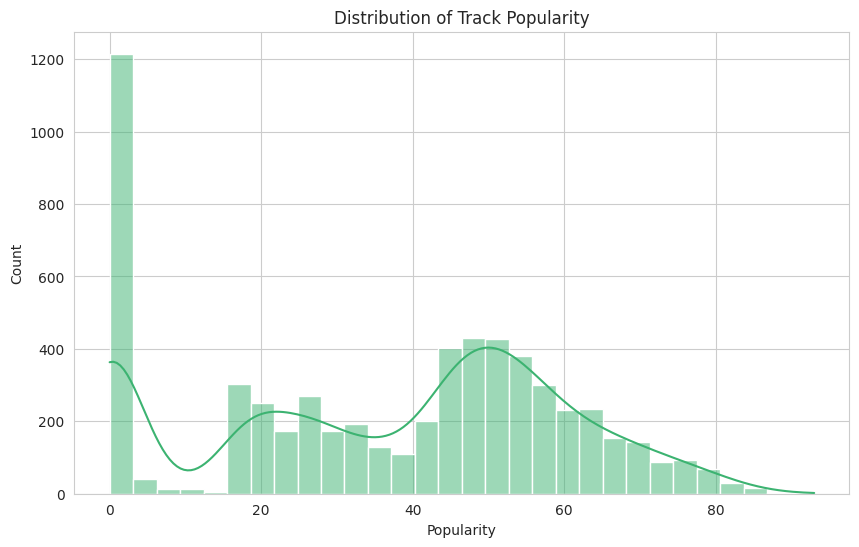

In [9]:
plt.figure()
sns.histplot(df['popularity'], bins=30, kde=True,color='mediumseagreen')
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.show()

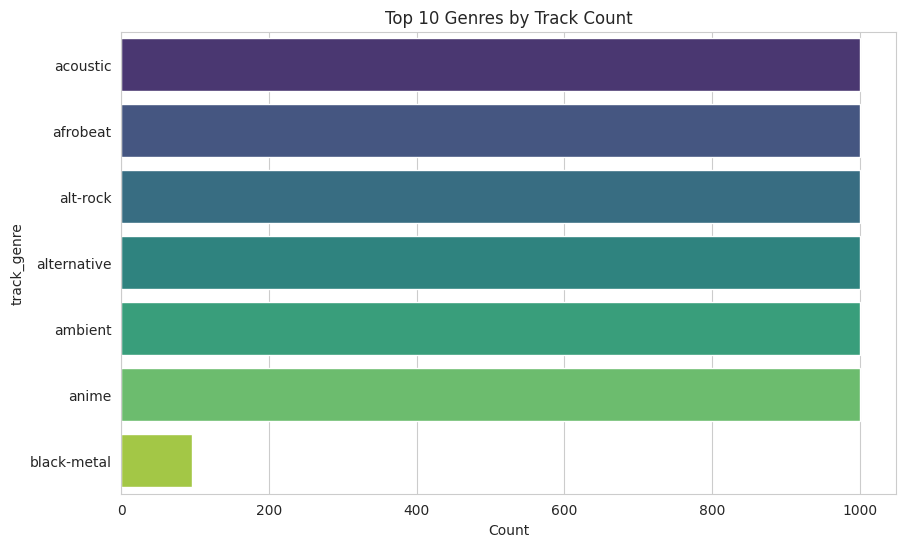

In [10]:
plt.figure()
top_genres = df['track_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
plt.title("Top 10 Genres by Track Count")
plt.xlabel("Count")
plt.show()

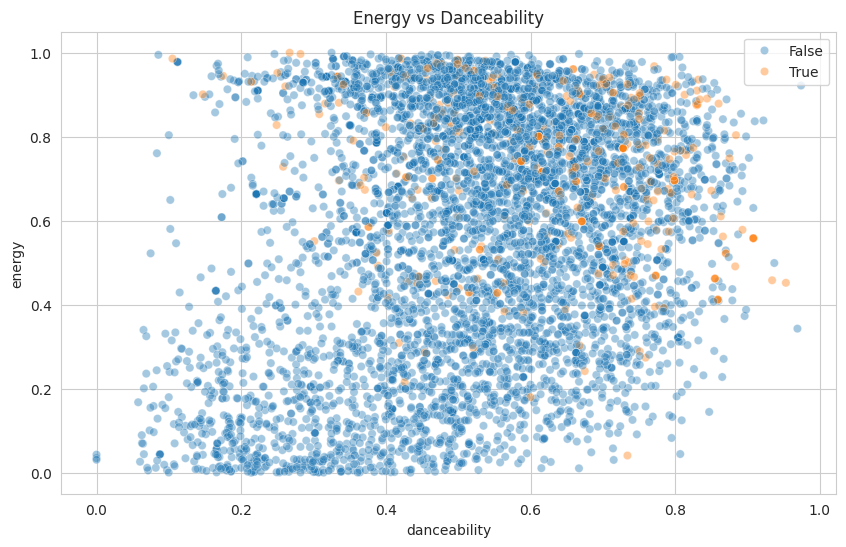

In [11]:
plt.figure()
sns.scatterplot(data=df, x='danceability', y='energy', alpha=0.4, hue='explicit')
plt.title("Energy vs Danceability")
plt.legend(loc='upper right')
plt.show()

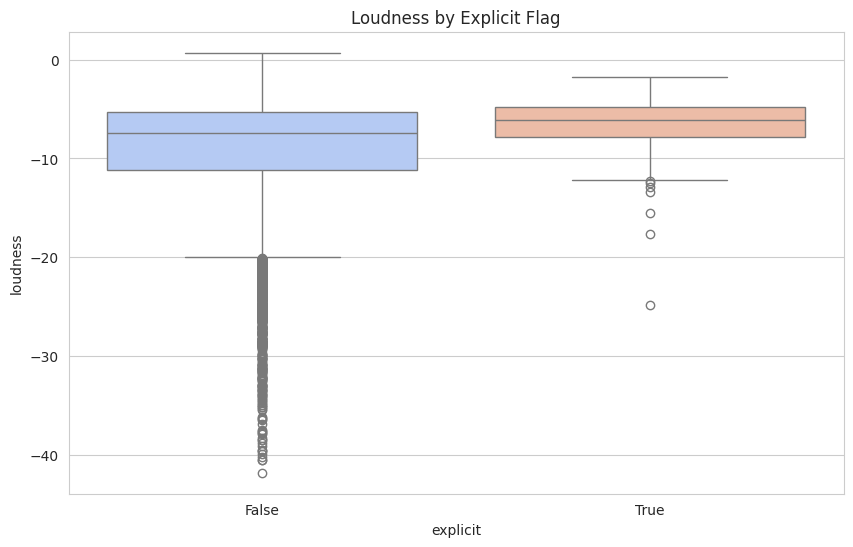

In [12]:
plt.figure()
sns.boxplot(data=df, x='explicit', y='loudness', hue='explicit', palette='coolwarm', legend=False)
plt.title("Loudness by Explicit Flag")
plt.show()

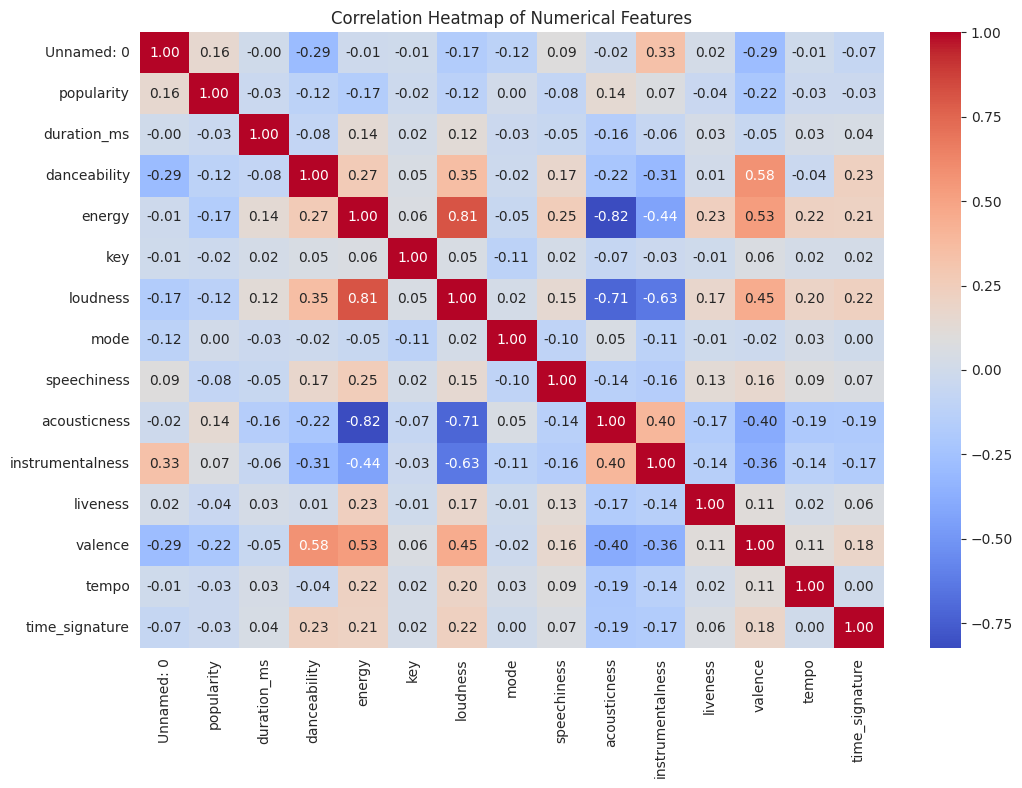

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

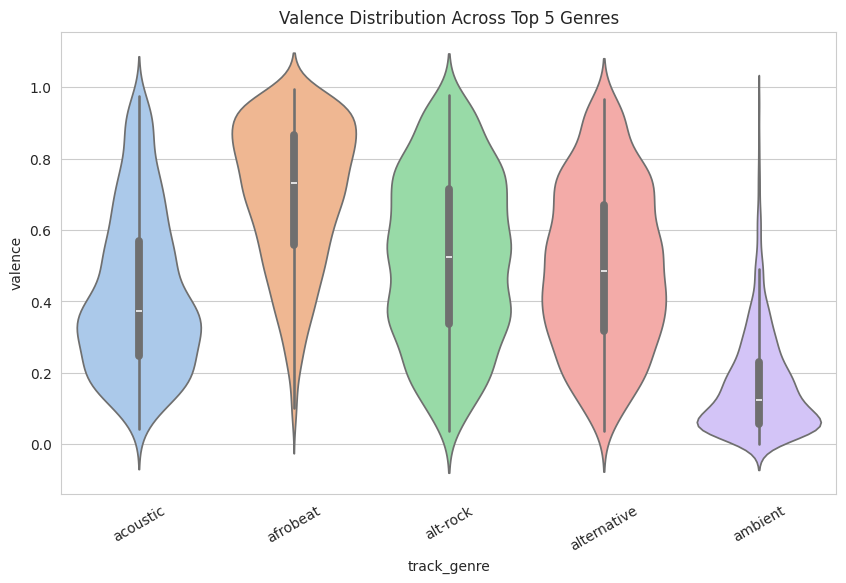

In [14]:
top5 = df['track_genre'].value_counts().head(5).index
subset = df[df['track_genre'].isin(top5)]
plt.figure()
sns.violinplot(data=subset, x='track_genre', y='valence', hue='track_genre', palette='pastel', legend=False)
plt.title("Valence Distribution Across Top 5 Genres")
plt.xticks(rotation=30)
plt.show()

# Overall Findings

- Most songs have moderate popularity.
- High-energy songs are common in the dataset.
- Danceability alone does not guarantee popularity.
- Energy and loudness are positively correlated.
- Pop and Rock genres are highly represented.
- Most tracks are non-explicit.
- Artist contributions are uneven, with a few artists having many tracks.